In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from geotransformer.datasets.registration.threedmatch.dataset import ThreeDMatchPairDataset
from geotransformer.utils.data import registration_collate_fn_stack_mode
from geotransformer.utils.torch import to_cuda, release_cuda
from geotransformer.modules.ops.pairwise_distance import pairwise_distance

from config_dowsampled import make_cfg
from model import create_model

In [28]:
# ---- constants ----
WEIGHTS = "../../output/geotransformer.facesdownsampledfixed.stage4.gse.k3.max.oacl.stage2.sinkhorn/snapshots/epoch-86.pth.tar"
N_SAMPLES = 20
POSITIVE_OVERLAP = 0.1   # cfg.coarse_loss.positive_overlap
NEIGHBOR_LIMITS = [38, 36, 36, 38]

In [29]:
cfg = make_cfg()
model = create_model(cfg).cuda()
model.eval()
state_dict = torch.load(WEIGHTS, weights_only=False)
model.load_state_dict(state_dict["model"])
model.neighbor_limits = NEIGHBOR_LIMITS
print(f"Loaded epoch-86 checkpoint")
print(f"matching_radius = {model.matching_radius}")

Loaded epoch-86 checkpoint
matching_radius = 0.05


In [30]:
val_dataset = ThreeDMatchPairDataset(
    cfg.data.dataset_root,
    'val',
    point_limit=None,
    use_augmentation=False,
)
print(f"Val dataset: {len(val_dataset)} samples")

Val dataset: 500 samples


In [31]:
stats = []

for i in range(N_SAMPLES):
    sample = val_dataset[i]
    data_dict = registration_collate_fn_stack_mode(
        [sample], cfg.backbone.num_stages, cfg.backbone.init_voxel_size,
        cfg.backbone.init_radius, NEIGHBOR_LIMITS, precompute_data=False
    )
    data_dict = to_cuda(data_dict)

    with torch.no_grad():
        output_dict = model(data_dict)

    gt_overlaps  = output_dict['gt_node_corr_overlaps'].cpu()
    gt_indices   = output_dict['gt_node_corr_indices'].cpu()
    ref_feats    = output_dict['ref_feats_c'].cpu()
    src_feats    = output_dict['src_feats_c'].cpu()
    ref_pts_c    = output_dict['ref_points_c'].cpu()
    src_pts_c    = output_dict['src_points_c'].cpu()
    pred_ref     = output_dict['ref_node_corr_indices'].cpu()
    pred_src     = output_dict['src_node_corr_indices'].cpu()
    morphed_full = output_dict['morphed_full'].cpu()
    recon_gt     = output_dict['recon_gt_points'].cpu()

    n_ref_sp = ref_pts_c.shape[0]
    n_src_sp = src_pts_c.shape[0]

    # --- A: GT positive pairs ---
    pos_mask = gt_overlaps > POSITIVE_OVERLAP
    n_pos = pos_mask.sum().item()
    pos_ref_idx = gt_indices[pos_mask, 0]
    pos_src_idx = gt_indices[pos_mask, 1]
    gt_pos_set = set(zip(pos_ref_idx.tolist(), pos_src_idx.tolist()))

    # --- B: Feature distances ---
    feat_dists_mat = torch.sqrt(pairwise_distance(ref_feats, src_feats, normalized=True))
    pos_dists = feat_dists_mat[pos_ref_idx, pos_src_idx].numpy() if n_pos > 0 else np.array([])

    flat = feat_dists_mat.flatten()
    neg_flat_mask = torch.ones(n_ref_sp * n_src_sp, dtype=torch.bool)
    for ri, si in gt_pos_set:
        neg_flat_mask[ri * n_src_sp + si] = False
    neg_dists_all = flat[neg_flat_mask].numpy()
    if len(neg_dists_all) > 5000:
        neg_dists_all = neg_dists_all[np.random.choice(len(neg_dists_all), 5000, replace=False)]

    # --- C: Morph quality ---
    morph_error = torch.norm(morphed_full - recon_gt, dim=1).mean().item()

    # --- D: PIR ---
    pred_set = set(zip(pred_ref.tolist(), pred_src.tolist()))
    n_correct = sum(1 for r, s in pred_set if (r, s) in gt_pos_set)
    pir = n_correct / max(len(pred_set), 1)

    stats.append({
        'n_pos': n_pos, 'n_ref_sp': n_ref_sp, 'n_src_sp': n_src_sp,
        'overlaps': gt_overlaps[pos_mask].numpy() if n_pos > 0 else np.array([]),
        'pos_dists': pos_dists, 'neg_dists': neg_dists_all,
        'pir': pir, 'morph_error': morph_error,
    })

    release_cuda(data_dict)
    release_cuda(output_dict)

    print(f"[{i+1:2d}/{N_SAMPLES}] n_pos={n_pos:3d}  n_ref_sp={n_ref_sp}  n_src_sp={n_src_sp}  PIR={pir:.3f}  morph_err={morph_error:.4f}")

print("\nDone.")

[ 1/20] n_pos=299  n_ref_sp=395  n_src_sp=167  PIR=0.324  morph_err=0.0206
[ 2/20] n_pos=123  n_ref_sp=397  n_src_sp=134  PIR=0.176  morph_err=0.0207
[ 3/20] n_pos=289  n_ref_sp=396  n_src_sp=170  PIR=0.363  morph_err=0.0259
[ 4/20] n_pos=373  n_ref_sp=395  n_src_sp=159  PIR=0.547  morph_err=0.0260
[ 5/20] n_pos=320  n_ref_sp=395  n_src_sp=161  PIR=0.203  morph_err=0.0378
[ 6/20] n_pos=257  n_ref_sp=396  n_src_sp=117  PIR=0.387  morph_err=0.0378
[ 7/20] n_pos=437  n_ref_sp=396  n_src_sp=171  PIR=0.680  morph_err=0.0255
[ 8/20] n_pos=493  n_ref_sp=396  n_src_sp=176  PIR=0.805  morph_err=0.0255
[ 9/20] n_pos=475  n_ref_sp=393  n_src_sp=163  PIR=0.539  morph_err=0.0204
[10/20] n_pos=288  n_ref_sp=398  n_src_sp=130  PIR=0.559  morph_err=0.0204
[11/20] n_pos=257  n_ref_sp=397  n_src_sp=165  PIR=0.398  morph_err=0.0148
[12/20] n_pos=269  n_ref_sp=396  n_src_sp=132  PIR=0.527  morph_err=0.0149
[13/20] n_pos=350  n_ref_sp=396  n_src_sp=166  PIR=0.598  morph_err=0.0319
[14/20] n_pos=374  n_ref_

## Diagnostic A — GT label quality
**Question**: Does the circle loss have enough positive pairs to train on?
- If average < 5 positive pairs per sample, the signal is too sparse regardless of feature quality.

GT positive pairs per sample:  mean=318.6  min=7  max=493
Ref Stage-4 superpoints:  395
Src Stage-4 superpoints:  mean=158


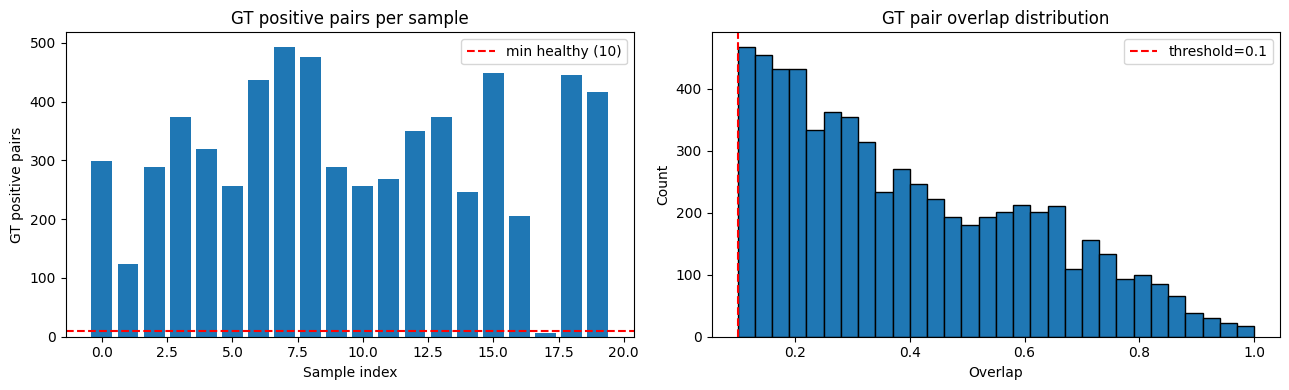

In [32]:
n_pos_arr = [s['n_pos'] for s in stats]
print(f"GT positive pairs per sample:  mean={np.mean(n_pos_arr):.1f}  min={np.min(n_pos_arr)}  max={np.max(n_pos_arr)}")
print(f"Ref Stage-4 superpoints:  {stats[0]['n_ref_sp']}")
print(f"Src Stage-4 superpoints:  mean={np.mean([s['n_src_sp'] for s in stats]):.0f}")

all_overlaps = np.concatenate([s['overlaps'] for s in stats if len(s['overlaps']) > 0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(n_pos_arr)), n_pos_arr)
axes[0].axhline(10, color='r', linestyle='--', label='min healthy (10)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('GT positive pairs')
axes[0].set_title('GT positive pairs per sample')
axes[0].legend()

axes[1].hist(all_overlaps, bins=30, edgecolor='k')
axes[1].axvline(POSITIVE_OVERLAP, color='r', linestyle='--', label=f'threshold={POSITIVE_OVERLAP}')
axes[1].set_xlabel('Overlap')
axes[1].set_ylabel('Count')
axes[1].set_title('GT pair overlap distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Diagnostic B — Feature discriminability
**Question**: Are the backbone features actually useful for matching?
- Healthy: positive pair distances clearly lower than negatives (large separation gap)
- Unhealthy: distributions overlap heavily → backbone not discriminating

Positive feat distance:  mean=0.827  std=0.062
Negative feat distance:  mean=1.302  std=0.211
Separation (neg - pos):  0.476
  ✓ Meaningful separation


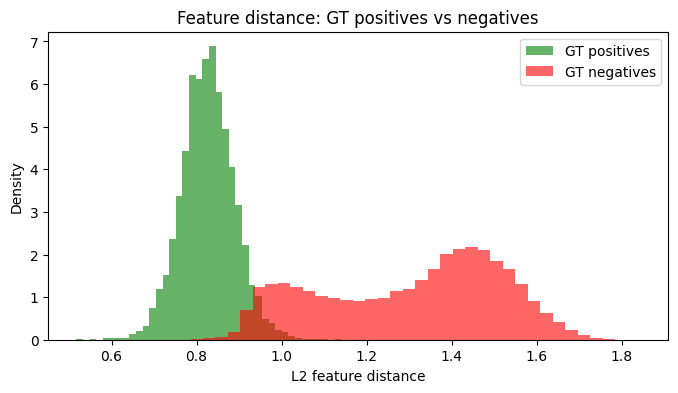

In [33]:
all_pos_dists = np.concatenate([s['pos_dists'] for s in stats if len(s['pos_dists']) > 0])
all_neg_dists = np.concatenate([s['neg_dists'] for s in stats if len(s['neg_dists']) > 0])

sep = all_neg_dists.mean() - all_pos_dists.mean()
print(f"Positive feat distance:  mean={all_pos_dists.mean():.3f}  std={all_pos_dists.std():.3f}")
print(f"Negative feat distance:  mean={all_neg_dists.mean():.3f}  std={all_neg_dists.std():.3f}")
print(f"Separation (neg - pos):  {sep:.3f}")
if sep < 0.2:
    print("  ⚠ Low separation — features are not discriminative")
else:
    print("  ✓ Meaningful separation")

plt.figure(figsize=(8, 4))
plt.hist(all_pos_dists, bins=40, alpha=0.6, label='GT positives', color='green', density=True)
plt.hist(all_neg_dists, bins=40, alpha=0.6, label='GT negatives', color='red', density=True)
plt.xlabel('L2 feature distance')
plt.ylabel('Density')
plt.title('Feature distance: GT positives vs negatives')
plt.legend()
plt.show()

## Diagnostic C — Morph quality
**Question**: Is the predicted morphing (pred_z) close enough to GT morphing (gt_z)?
- If morph error >> matching_radius (0.05), GT labels computed with predicted ref are unreliable.

Mean per-point morph error (pred vs GT): 0.0268 m
matching_radius = 0.050 m
Error / matching_radius = 0.54x
  ⚠ Morph error is large relative to matching radius — GT labels may be corrupted


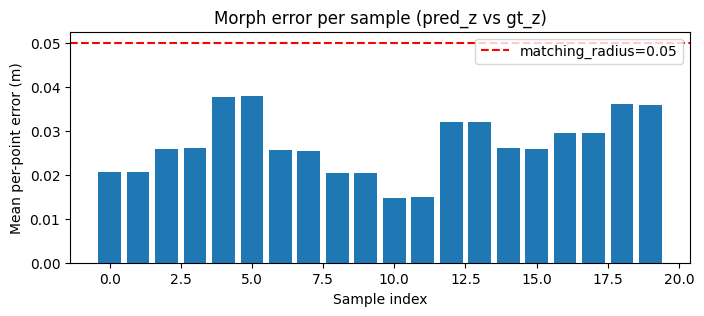

In [34]:
morph_errors = [s['morph_error'] for s in stats]
print(f"Mean per-point morph error (pred vs GT): {np.mean(morph_errors):.4f} m")
print(f"matching_radius = {model.matching_radius:.3f} m")
ratio = np.mean(morph_errors) / model.matching_radius
print(f"Error / matching_radius = {ratio:.2f}x")
if ratio > 0.5:
    print("  ⚠ Morph error is large relative to matching radius — GT labels may be corrupted")
else:
    print("  ✓ Morph error is small — not the bottleneck")

plt.figure(figsize=(8, 3))
plt.bar(range(len(morph_errors)), morph_errors)
plt.axhline(model.matching_radius, color='r', linestyle='--', label=f'matching_radius={model.matching_radius}')
plt.xlabel('Sample index')
plt.ylabel('Mean per-point error (m)')
plt.title('Morph error per sample (pred_z vs gt_z)')
plt.legend()
plt.show()

## Diagnostic D — Predicted PIR per sample
**Question**: Is PIR uniform across samples, or are some systematically hard?

PIR per sample:  mean=0.462  min=0.012  max=0.816


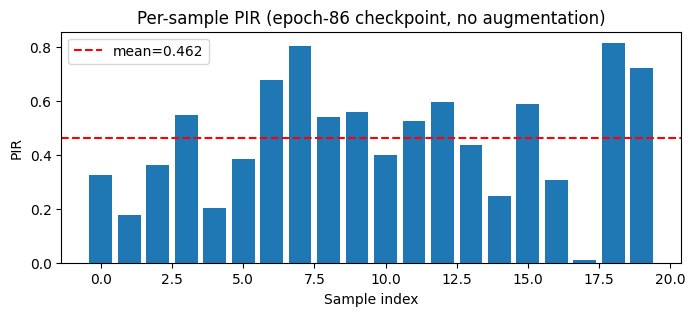

In [35]:
pir_arr = [s['pir'] for s in stats]
print(f"PIR per sample:  mean={np.mean(pir_arr):.3f}  min={np.min(pir_arr):.3f}  max={np.max(pir_arr):.3f}")

plt.figure(figsize=(8, 3))
plt.bar(range(len(pir_arr)), pir_arr)
plt.axhline(np.mean(pir_arr), color='r', linestyle='--', label=f'mean={np.mean(pir_arr):.3f}')
plt.xlabel('Sample index')
plt.ylabel('PIR')
plt.title('Per-sample PIR (epoch-86 checkpoint, no augmentation)')
plt.legend()
plt.show()

In [36]:
print("=== Summary ===")
print(f"  Avg GT positive pairs:   {np.mean([s['n_pos'] for s in stats]):.1f}")
print(f"  Feature separation:      {all_neg_dists.mean() - all_pos_dists.mean():.3f}")
print(f"  Avg morph error:         {np.mean(morph_errors):.4f} m  ({np.mean(morph_errors)/model.matching_radius:.2f}x matching_radius)")
print(f"  Avg PIR:                 {np.mean(pir_arr):.3f}")

=== Summary ===
  Avg GT positive pairs:   318.6
  Feature separation:      0.476
  Avg morph error:         0.0268 m  (0.54x matching_radius)
  Avg PIR:                 0.462


---
## Augmentation Ablation
Isolates which augmentation drives the PIR gap (0.46 clean → ~0.22 training val).

`_augment_point_cloud` applies two things when `use_augmentation=True`: extra **rotation** and **noise**.  
Scale/subsampling are train-only (val fixes them at 1.0) so they are not tested here.

| Condition | rotation | noise |
|---|---|---|
| A | 0 | 0 |
| B | 1.0 | 0 |
| C | 0 | 0.01 |
| D | 1.0 | 0.01 |

In [37]:
def run_ablation(aug_rotation, aug_noise, aug_scale=1.0, aug_subsample=1.0, force_shuffle=False, n_samples=20):
    use_aug = force_shuffle or aug_rotation > 0 or aug_noise > 0 or aug_scale != 1.0 or aug_subsample != 1.0
    dataset = ThreeDMatchPairDataset(
        cfg.data.dataset_root,
        'val',
        point_limit=None,
        use_augmentation=use_aug,
        augmentation_noise=aug_noise,
        augmentation_rotation=aug_rotation,
        aug_scale_min=aug_scale,
        aug_scale_max=aug_scale,
        aug_subsample_keep_min=aug_subsample,
    )
    pirs = []
    for i in range(n_samples):
        sample = dataset[i]
        data_dict = registration_collate_fn_stack_mode(
            [sample], cfg.backbone.num_stages, cfg.backbone.init_voxel_size,
            cfg.backbone.init_radius, NEIGHBOR_LIMITS, precompute_data=False
        )
        data_dict = to_cuda(data_dict)
        with torch.no_grad():
            output_dict = model(data_dict)
        gt_overlaps = output_dict['gt_node_corr_overlaps'].cpu()
        gt_indices  = output_dict['gt_node_corr_indices'].cpu()
        pred_ref    = output_dict['ref_node_corr_indices'].cpu()
        pred_src    = output_dict['src_node_corr_indices'].cpu()
        pos_mask    = gt_overlaps > POSITIVE_OVERLAP
        gt_pos_set  = set(zip(gt_indices[pos_mask, 0].tolist(), gt_indices[pos_mask, 1].tolist()))
        pred_set    = set(zip(pred_ref.tolist(), pred_src.tolist()))
        n_correct   = sum(1 for r, s in pred_set if (r, s) in gt_pos_set)
        pirs.append(n_correct / max(len(pred_set), 1))
        release_cuda(data_dict)
        release_cuda(output_dict)
    return float(np.mean(pirs))

In [38]:
N_ABL = 20

# (label, rotation, noise, scale, subsample, force_shuffle)
conditions = [
    # --- Baseline ---
    ('A  no aug (baseline)',         0.0,  0.0,   1.0,  1.0,  False),
    # --- Single-factor isolation ---
    ('B  shuffle only',              0.0,  0.0,   1.0,  1.0,  True),
    ('C  rotation only',             1.0,  0.0,   1.0,  1.0,  False),
    ('D  noise only',                0.0,  0.01,  1.0,  1.0,  False),
    ('E  subsample=0.5 only',        0.0,  0.0,   1.0,  0.5,  False),
    ('F  subsample=0.7 only',        0.0,  0.0,   1.0,  0.7,  False),
    ('G  scale=0.6 only',            0.0,  0.0,   0.6,  1.0,  False),
    ('H  scale=0.8 only',            0.0,  0.0,   0.8,  1.0,  False),
    ('I  scale=1.2 only',            0.0,  0.0,   1.2,  1.0,  False),
    ('J  scale=1.4 only',            0.0,  0.0,   1.4,  1.0,  False),
    # --- Training val (rotation + noise, scale/subsample fixed at 1.0) ---
    ('K  rot+noise (training val)',  1.0,  0.01,  1.0,  1.0,  False),
    # --- Worst-case combos ---
    ('L  all aug, scale=0.6',        1.0,  0.01,  0.6,  0.5,  False),
    ('M  all aug, scale=1.4',        1.0,  0.01,  1.4,  0.5,  False),
]

results = []
for label, rot, noise, scale, subsample, shuffle in conditions:
    pir = run_ablation(rot, noise, scale, subsample, shuffle, N_ABL)
    results.append((label, pir))
    print(f"{label:<35}  PIR={pir:.3f}")

A  no aug (baseline)                 PIR=0.462
B  shuffle only                      PIR=0.462
C  rotation only                     PIR=0.182
D  noise only                        PIR=0.465
E  subsample=0.5 only                PIR=0.356
F  subsample=0.7 only                PIR=0.433
G  scale=0.6 only                    PIR=0.449
H  scale=0.8 only                    PIR=0.457
I  scale=1.2 only                    PIR=0.412
J  scale=1.4 only                    PIR=0.463
K  rot+noise (training val)          PIR=0.203
L  all aug, scale=0.6                PIR=0.205
M  all aug, scale=1.4                PIR=0.134


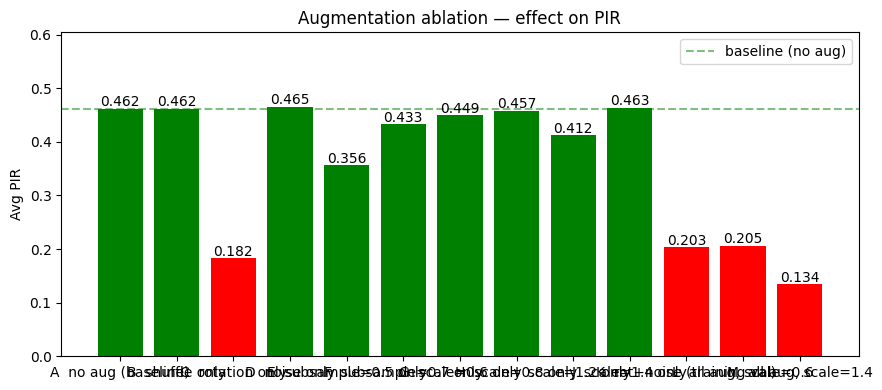

PIR drop from rotation:  0.000
PIR drop from noise:     0.279


In [39]:
labels   = [r[0] for r in results]
pir_vals = [r[1] for r in results]
colors   = ['green' if p > 0.35 else 'orange' if p > 0.25 else 'red' for p in pir_vals]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, pir_vals, color=colors)
plt.axhline(pir_vals[0], color='green', linestyle='--', alpha=0.5, label='baseline (no aug)')
plt.ylim(0, max(pir_vals) * 1.3)
plt.ylabel('Avg PIR')
plt.title('Augmentation ablation — effect on PIR')
for bar, val in zip(bars, pir_vals):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

drop_B = pir_vals[0] - pir_vals[1]
drop_C = pir_vals[0] - pir_vals[2]
print(f"PIR drop from rotation:  {drop_B:.3f}")
print(f"PIR drop from noise:     {drop_C:.3f}")